<a href="https://colab.research.google.com/github/NishanRegmi/Deep-Learning/blob/main/catvsdog_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nishanregmi","key":"0ba7d0f274d2dbc6a02e50f9d3aacd99"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle competitions download -c dogs-vs-cats

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [4]:
!kaggle datasets list -s "cats dogs"

ref                                                        title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset                 Cats-vs-Dogs                                         825979578  2020-03-12 05:34:30.730000         106283        961  0.875            
marquis03/cats-and-dogs                                    Cats and Dogs                                         10219362  2023-10-27 10:48:19.220000          16442        142  1                
chetankv/dogs-cats-images                                  Dogs & Cats Images                                   455718914  2018-04-19 18:20:08.593000          51512        620  0.5625           
mmoreaux/audio-cats-and-d

In [5]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:45<00:00, 18.0MB/s]



In [6]:
# =========================
# 4. Unzip Dataset
# =========================
!unzip -q microsoft-catsvsdogs-dataset.zip -d catsdogs

In [7]:
# =========================
# 5. Check Folder Structure
# =========================
import os

for root, dirs, files in os.walk("/content/catsdogs"):
    if len(files) > 0:
        print(root, len(files))

/content/catsdogs 2
/content/catsdogs/PetImages/Dog 12501
/content/catsdogs/PetImages/Cat 12501


In [8]:
# =========================
# 6. Remove Corrupted Images
# =========================
from PIL import Image
from pathlib import Path

dataset_dir = Path("/content/catsdogs/PetImages")

bad_files = []

for img_path in dataset_dir.rglob("*.jpg"):
    try:
        img = Image.open(img_path)
        img.verify()
    except:
        bad_files.append(img_path)

for bad_file in bad_files:
    bad_file.unlink()

print("Removed bad images:", len(bad_files))

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removed bad images: 2


In [10]:
# =========================
# 7. Keras ImageDataGenerator
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [13]:
from keras import Sequential
from keras.layers import Conv2D, Dense, Dropout, MaxPooling2D, Flatten

In [14]:
model = Sequential()

In [15]:
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,281 (42.64 MB)

 Trainable params: 11,177,281 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
451/625 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.5886 - loss: 0.6713

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.6734 - loss: 0.5924 - val_accuracy: 0.7625 - val_loss: 0.4934
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.7821 - loss: 0.4607 - val_accuracy: 0.7885 - val_loss: 0.4496
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.8349 - loss: 0.3723 - val_accuracy: 0.8115 - val_loss: 0.4156
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.8920 - loss: 0.2547 - val_accuracy: 0.8179 - val_loss: 0.4254
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.9502 - loss: 0.1312 - val_accuracy: 0.7973 - val_loss: 0.6306
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.9771 - loss: 0.0656 - val_accuracy: 0.8003 - val_loss: 0.7950
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9847 - loss: 0.0456 - val_accuracy: 0.8039 - val_loss: 0.9340
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9898 - loss: 0.0326 - val_accura

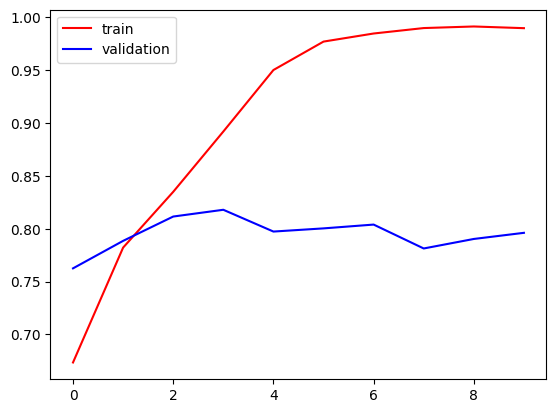

In [20]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

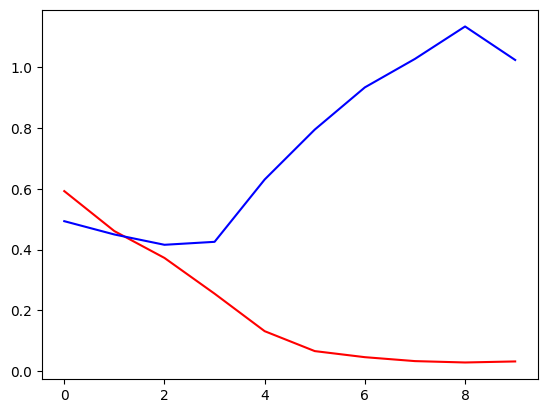

In [21]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.show()

There is clear indication about the overfitting. Lets try to overcome the overfitting by introducing dropout and batch normalization

In [22]:
from keras.layers import Dropout, BatchNormalization

In [23]:
model = Sequential()

In [24]:
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,177 (42.64 MB)

 Trainable params: 11,177,729 (42.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
 73/625 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.5659 - loss: 3.2300

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.6061 - loss: 0.9599 - val_accuracy: 0.6158 - val_loss: 0.6602
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7365 - loss: 0.5306 - val_accuracy: 0.7281 - val_loss: 0.5449
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 90ms/step - accuracy: 0.7982 - loss: 0.4410 - val_accuracy: 0.7433 - val_loss: 0.5211
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.8394 - loss: 0.3701 - val_accuracy: 0.7901 - val_loss: 0.4308
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8741 - loss: 0.3021 - val_accuracy: 0.8229 - val_loss: 0.3925
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.9097 - loss: 0.2207 - val_accuracy: 0.6158 - val_loss: 2.4450
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.9334 - loss: 0.1693 - val_accuracy: 0.7585 - val_loss: 0.6574
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.9550 - loss: 0.1146 - val_accurac

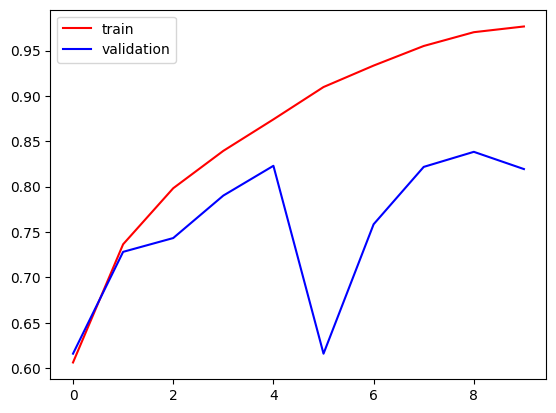

In [28]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

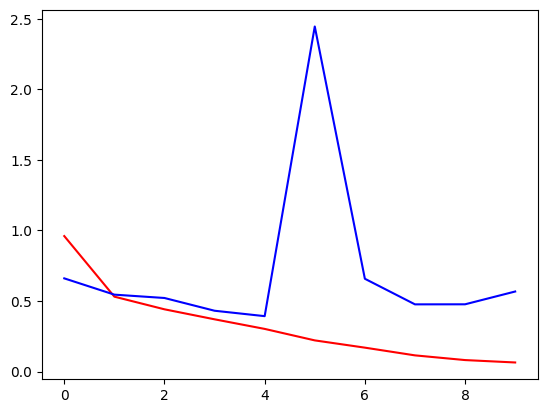

In [29]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.show()

array([[[ 36,  62,  49],
        [ 34,  60,  47],
        [ 31,  57,  44],
        ...,
        [ 37,  60,  52],
        [ 37,  60,  52],
        [ 37,  60,  52]],

       [[ 35,  61,  48],
        [ 33,  59,  46],
        [ 30,  56,  43],
        ...,
        [ 37,  60,  52],
        [ 37,  60,  52],
        [ 37,  60,  52]],

       [[ 33,  59,  46],
        [ 31,  57,  44],
        [ 29,  55,  42],
        ...,
        [ 38,  60,  55],
        [ 38,  60,  55],
        [ 38,  60,  55]],

       ...,

       [[107, 166, 162],
        [ 89, 149, 143],
        [ 70, 128, 123],
        ...,
        [127, 175, 169],
        [110, 157, 154],
        [ 84, 131, 128]],

       [[106, 168, 162],
        [ 78, 141, 132],
        [ 79, 138, 130],
        ...,
        [157, 202, 205],
        [143, 188, 191],
        [155, 203, 205]],

       [[ 80, 145, 136],
        [ 68, 131, 122],
        [ 88, 147, 139],
        ...,
        [159, 203, 210],
        [121, 165, 172],
        [106, 152, 159]]], dtype=uint8)
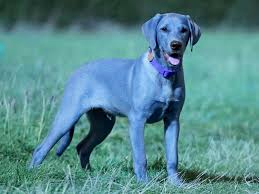

In [32]:
#prediction
import cv2
test_img = cv2.imread('/content/dog.jpg')
test_img

In [37]:
test_img.shape

(194, 259, 3)

In [38]:
test_img = cv2.resize(test_img, (224, 224))
test_input = test_img.reshape((1, 224, 224, 3))

In [39]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step


array([[0.]], dtype=float32)

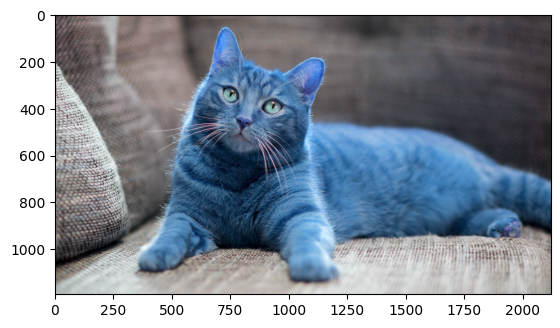

In [35]:
test_cat = cv2.imread('/content/cat.jpg')
plt.imshow(test_cat)

In [40]:
test_cat.shape

(1193, 2121, 3)

In [41]:
test_cat = cv2.resize(test_cat, (224, 224))

In [42]:
cat_input = test_cat.reshape(1, 224, 224, 3)

In [43]:
model.predict(cat_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[1.96671e-28]], dtype=float32)